# Time-Series

In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              131.8595539521603,
              -0.24378014489177247
            ],
            [
              134.48844572156236,
              -0.24378014489177247
            ],
            [
              134.48843876611602,
              -2.315227200543717
            ],
            [
              131.8595539521603,
              -2.315228446256455
            ],
            [
              131.8595539521603,
              -0.24378014489177247
            ]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [5]:
job = s5post.execute_batch(title="NO2 in Papua", outputfile="NO2Papua.nc")

0:00:00 Job 'j-260603035931457cb89ac6c1477e90bc': send 'start'
0:00:05 Job 'j-260603035931457cb89ac6c1477e90bc': queued (progress 0%)
0:00:11 Job 'j-260603035931457cb89ac6c1477e90bc': queued (progress 0%)
0:00:18 Job 'j-260603035931457cb89ac6c1477e90bc': queued (progress 0%)
0:00:26 Job 'j-260603035931457cb89ac6c1477e90bc': queued (progress 0%)
0:00:36 Job 'j-260603035931457cb89ac6c1477e90bc': queued (progress 0%)
0:00:53 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:01:09 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:01:29 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:01:53 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:02:23 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:03:01 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:03:48 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A)
0:04:48 Job 'j-260603035931457cb89ac6c1477e90bc': running (progress N/A

In [11]:
import netCDF4

file_path = "data/NO2Papua.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
725
9
8
3.7701793e-05


In [14]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[3.770179318962619e-05 4.4227883336134255e-05 2.893842975026928e-05
  2.7030169803765602e-05 2.3806940589565784e-05 2.586452137620654e-05
  1.6022562704165466e-05 9.385486009705346e-06]
 [3.770179318962619e-05 3.1096213206183165e-05 3.226231274311431e-05
  2.7030169803765602e-05 2.2647607693215832e-05 3.680306326714344e-05
  1.6022562704165466e-05 3.747334631043486e-05]
 [2.7158148441230878e-05 3.1096213206183165e-05 4.294700556783937e-05
  2.0787138055311516e-05 2.2647607693215832e-05 3.6170044040773064e-05
  2.544464950915426e-05 2.3946160581544973e-05]
 [2.9651806471520104e-05 3.772687341552228e-05 4.294700556783937e-05
  5.6563803809694946e-05 4.394538700580597e-05 3.6170044040773064e-05
  6.348737952066585e-05 3.904499681084417e-05]
 [2.9651806471520104e-05 4.1052295273402706e-05 -- 5.6563803809694946e-05
  -- -- 6.348737952066585e-05 --]
 [3.303916673758067e-05 4.1052295273402706e-05 1.2694688848569058e-05 --
  -- -- -- --]
 [1.5709914805484004e-05 3.2586256

In [15]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

In [16]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

In [18]:
df = pd.DataFrame({
    "date": dates,
    "NO2": no2_filled.mean(axis=(1, 2))  # rata-rata NO2 per tanggal
})

# Simpan ke CSV
df.to_csv("NO2_Papua_timeseries.csv", index=False)

In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Papua_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 6
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


In [26]:
import pandas as pd

# Pastikan datetime dan sorting
# Pastikan datetime dan sorting
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')
else:
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated_papua.csv")
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated_papua.csv")

C:\Users\asus\AppData\Local\Temp\ipykernel_11460\2428567186.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


KeyError: "None of ['date'] are in the columns"

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("no2_timeseries_interpolated.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 14
         date       NO2
45 2023-11-15  0.000051
46 2023-11-16  0.000044
48 2023-11-18  0.000051
67 2023-12-07  0.000047
68 2023-12-08  0.000045


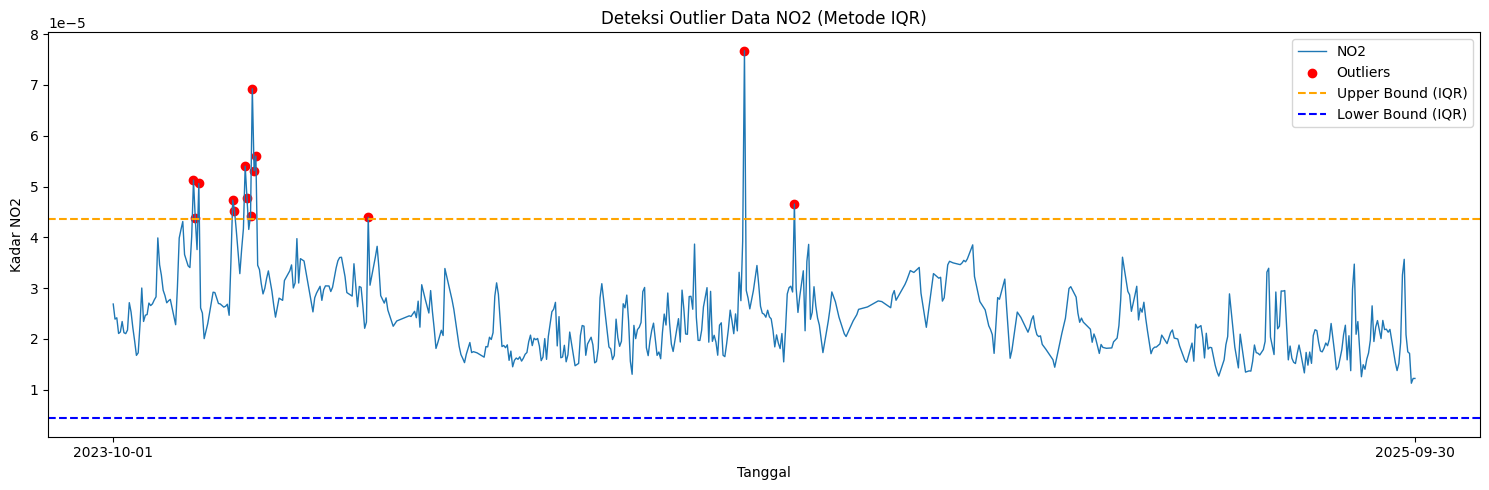

In [ ]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], 
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [ ]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 14
Jumlah missing setelah interpolasi: 0


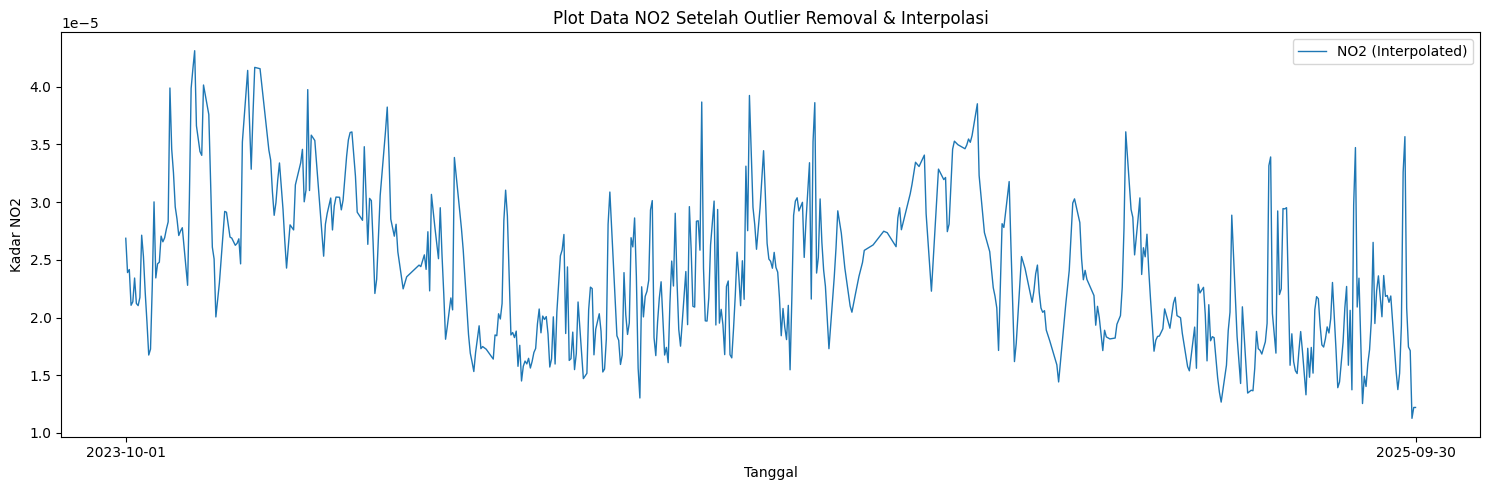

In [ ]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()